# ANALYSE DE FICHIERS VOLUMINEUX 


## 1/ Créer un fichier adapté (memory mapped file)

In [1]:
import vaex as vx

import pandas as pd
import numpy as np
import pylab
import json
import sys
from IPython.display import display
import ipywidgets as widgets
from tqdm import tqdm, tqdm_notebook, tnrange
import matplotlib.pyplot as plt
%matplotlib inline

ModuleNotFoundError: No module named 'vaex'

In [ ]:
#import vaex.ui.qt

In [2]:
filename =  "C:/Users/dgr/Documents/data/green_tripdata_2018-01.csv"

In [25]:
# Test de lecture du fichier
df = pd.read_csv(filename,nrows=10000)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               10000 non-null  int64  
 1   lpep_pickup_datetime   10000 non-null  object 
 2   lpep_dropoff_datetime  10000 non-null  object 
 3   store_and_fwd_flag     10000 non-null  object 
 4   RatecodeID             10000 non-null  int64  
 5   PULocationID           10000 non-null  int64  
 6   DOLocationID           10000 non-null  int64  
 7   passenger_count        10000 non-null  int64  
 8   trip_distance          10000 non-null  float64
 9   fare_amount            10000 non-null  float64
 10  extra                  10000 non-null  float64
 11  mta_tax                10000 non-null  float64
 12  tip_amount             10000 non-null  float64
 13  tolls_amount           10000 non-null  float64
 14  ehail_fee              0 non-null      float64
 15  imp

In [27]:
date_names = ["lpep_pickup_datetime","lpep_dropoff_datetime"]
# on parse les dates
df = pd.read_csv(filename, parse_dates=date_names,nrows=100000)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               100000 non-null  int64         
 1   lpep_pickup_datetime   100000 non-null  datetime64[ns]
 2   lpep_dropoff_datetime  100000 non-null  datetime64[ns]
 3   store_and_fwd_flag     100000 non-null  object        
 4   RatecodeID             100000 non-null  int64         
 5   PULocationID           100000 non-null  int64         
 6   DOLocationID           100000 non-null  int64         
 7   passenger_count        100000 non-null  int64         
 8   trip_distance          100000 non-null  float64       
 9   fare_amount            100000 non-null  float64       
 10  extra                  100000 non-null  float64       
 11  mta_tax                100000 non-null  float64       
 12  tip_amount             100000 non-null  float

In [36]:
df.columns

Index(['VendorID', 'lpep_pickup_datetime', 'lpep_dropoff_datetime',
       'RatecodeID', 'PULocationID', 'DOLocationID', 'passenger_count',
       'trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount',
       'tolls_amount', 'ehail_fee', 'improvement_surcharge', 'total_amount',
       'payment_type', 'trip_type'],
      dtype='object')

In [42]:
%%timeit
# LECTURE DU FICHIER TOTAL
date_names = ["lpep_pickup_datetime","lpep_dropoff_datetime"]
l=['VendorID', 'lpep_pickup_datetime', 'lpep_dropoff_datetime',
       'RatecodeID', 'PULocationID', 'DOLocationID', 'passenger_count',
       'trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount',
       'tolls_amount', 'ehail_fee', 'improvement_surcharge', 'total_amount',
       'payment_type', 'trip_type']

df = pd.read_csv(filename,parse_dates=date_names,usecols=l)
#del df["store_and_fwd_flag"]

3.06 s ± 124 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 793529 entries, 0 to 793528
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               793529 non-null  int64  
 1   lpep_pickup_datetime   793529 non-null  object 
 2   lpep_dropoff_datetime  793529 non-null  object 
 3   RatecodeID             793529 non-null  int64  
 4   PULocationID           793529 non-null  int64  
 5   DOLocationID           793529 non-null  int64  
 6   passenger_count        793529 non-null  int64  
 7   trip_distance          793529 non-null  float64
 8   fare_amount            793529 non-null  float64
 9   extra                  793529 non-null  float64
 10  mta_tax                793529 non-null  float64
 11  tip_amount             793529 non-null  float64
 12  tolls_amount           793529 non-null  float64
 13  ehail_fee              0 non-null       float64
 14  improvement_surcharge  793529 non-nu

In [48]:
# les deux dates ne sont pas reconnues
df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type
0,2,2018-01-01 00:18:50,2018-01-01 00:24:39,1,236,236,5,0.70,6.0,0.5,0.5,0.0,0.0,NaN,0.3,7.3,2,1.0
1,2,2018-01-01 00:30:26,2018-01-01 00:46:42,1,43,42,5,3.50,14.5,0.5,0.5,0.0,0.0,NaN,0.3,15.8,2,1.0
2,2,2018-01-01 00:07:25,2018-01-01 00:19:45,1,74,152,1,2.14,10.0,0.5,0.5,0.0,0.0,NaN,0.3,11.3,2,1.0
3,2,2018-01-01 00:32:40,2018-01-01 00:33:41,1,255,255,1,0.03,-3.0,-0.5,-0.5,0.0,0.0,NaN,-0.3,-4.3,3,1.0
4,2,2018-01-01 00:32:40,2018-01-01 00:33:41,1,255,255,1,0.03,3.0,0.5,0.5,0.0,0.0,NaN,0.3,4.3,2,1.0


In [55]:
df['lpep_pickup_datetime']=pd.to_datetime(df.lpep_pickup_datetime,infer_datetime_format=True)
df['lpep_dropoff_datetime']=pd.to_datetime(df.lpep_dropoff_datetime,infer_datetime_format=True)

In [54]:
#df.drop('pickupdt',axis=1,inplace=True)

In [56]:
df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type
0,2,2018-01-01 00:18:50,2018-01-01 00:24:39,1,236,236,5,0.70,6.0,0.5,0.5,0.0,0.0,NaN,0.3,7.3,2,1.0
1,2,2018-01-01 00:30:26,2018-01-01 00:46:42,1,43,42,5,3.50,14.5,0.5,0.5,0.0,0.0,NaN,0.3,15.8,2,1.0
2,2,2018-01-01 00:07:25,2018-01-01 00:19:45,1,74,152,1,2.14,10.0,0.5,0.5,0.0,0.0,NaN,0.3,11.3,2,1.0
3,2,2018-01-01 00:32:40,2018-01-01 00:33:41,1,255,255,1,0.03,-3.0,-0.5,-0.5,0.0,0.0,NaN,-0.3,-4.3,3,1.0
4,2,2018-01-01 00:32:40,2018-01-01 00:33:41,1,255,255,1,0.03,3.0,0.5,0.5,0.0,0.0,NaN,0.3,4.3,2,1.0


In [57]:
 # On convertit le fichier pandas en un fichier vaex dataset
dataset = vx.from_pandas(df)
# On ajoute des colonnes virtuelles qui seront crées lorsqu'on en aura besoin
dataset.add_virtual_column("pickup_hour", "dt_hour(lpep_pickup_datetime)")
dataset.add_virtual_column("dropoff_hour", "dt_hour(lpep_dropoff_datetime)")
dataset.add_virtual_column("pickup_dayofweek", "dt_dayofweek(lpep_pickup_datetime)")
dataset.add_virtual_column("dropoff_dayofweek", "dt_dayofweek(lpep_dropoff_datetime)")


In [4]:
 # Stocke le fichier sur disque sous un format "memory mapped"
filename_nyt = filename.replace(".csv", ".hdf5")
dataset.export_hdf5(filename_nyt, virtual=True)

## 2/ Analyse de fichier memory mapped avec VAEX

In [10]:
%%timeit
# ouvrir le fichier; c'est un  memory mapped file, vaex ne lit que ses méta données

nyt1 = vx.open(filename_nyt)

29.7 ms ± 5.68 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [6]:
nyt1.count()

array(793529, dtype=int64)

In [16]:
#%%timeit
# Utiliser la fonction describe ,All of these stats are computed with a single pass over the data.
nyt1.describe()
# le fichier fait 150 Mo, le temps estimé est 3''

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,...,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,pickup_hour,dropoff_hour,pickup_dayofweek,dropoff_dayofweek
dtype,int64,datetime64[ns],datetime64[ns],int64,int64,int64,int64,float64,float64,float64,...,float64,float64,float64,float64,int64,float64,int64,int64,int64,int64
count,789883,789883,789883,789883,789883,789883,789883,789883,789883,789883,...,789883,0,789883,789883,789883,789880,789883,789883,789883,789883
NA,0,0,0,0,0,0,0,0,0,0,...,0,789883,0,0,0,3,0,0,0,0
mean,1.8274352024287142,1970-01-01T05:48:21.792005789,1970-01-01T06:08:44.386407745,1.0674340376992542,109.94116090610888,128.61161842956488,1.36271447796699,2.67108051445613,11.804286710816642,0.34201103201360206,...,0.0855874857415656,nan,0.2950948431564406,14.08651719310647,1.4700291055763954,1.0164670582873347,13.816874144651804,13.861751677147122,2.8962074129966084,2.899062266183726
std,0.377871,1.31861e+15,1.31856e+15,0.5407,74.3887,77.1581,1.04736,2.84428,10.1219,0.393417,...,1.02368,NaN,0.0380458,11.0348,0.513851,0.127263,6.11778,6.18605,1.98385,1.98582
min,1,2009-01-01T10:21:13.321406464,2009-01-01T11:16:11.856289792,1,1,1,0,0,0,0,...,0,inf,0,0.01,1,1,0,0,0,0
max,2,2018-04-05T04:12:12.356378624,2018-04-05T04:25:56.990099456,99,265,265,9,140.62,2126,4.5,...,557.55,-inf,0.3,2126.8,5,2,23,23,6,6


In [17]:
# Lorsqu'on filtre, les données ne sont pas modifiées et cela ne créer pas de copie
# les données restent sur disque et sont processés lorsque nécessaire

nyt=nyt1[nyt1['total_amount']>0 and nyt.trip_distance>0 and nyt.trip_distance<100]

In [ ]:
# ce qui est intéressant, c'est que le filtrage ne génère pas de copie,  
# Seulement une référence à la data originale est créée avec un masque pour l'appliquer le filtrage


In [18]:
# les calculs sont out of core, la limite est la taille du disque
# filtres?
len(nyt)

789881

In [20]:
# examinnons la distribution de passenger count
nyt.passenger_count.value_counts(progress=True).sort_index()

[----------------------------------------] 100.00% elapsed time  :     0.00s =  0.0m =  0.0h
 

0       171
1    668673
2     59926
3     13588
4      5065
5     27960
6     14467
7        18
8        11
9         2
dtype: int64

In [ ]:
nyt=nyt[nyt.passenger_count>0 and nyt.passenger_count<7]

In [45]:
# quand on crée une colonne, on enregistre sa définition, sera évalué lorsque nécessaire

nyt['trip_duration_min']=(nyt['lpep_dropoff_datetime']-nyt['lpep_pickup_datetime'])/np.timedelta64(1,'m')


In [31]:
%matplotlib inline
plt.figure()


<Figure size 432x288 with 0 Axes>

<Figure size 432x288 with 0 Axes>

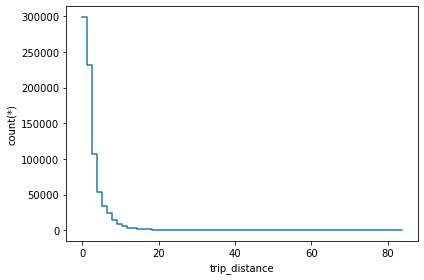

In [36]:
nyt.plot1d(nyt.trip_distance)

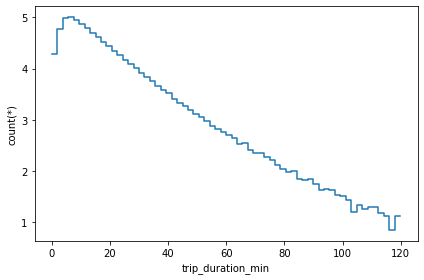

In [49]:
nyt.plot1d(nyt.trip_duration_min,f='log10')

C:\Users\dgr\AppData\Local\Continuum\anaconda3\lib\site-packages\vaex\viz\mpl.py:128: RuntimeWarning: divide by zero encountered in log10
  fgrid = f(grid)


Text(36.625, 0.5, 'Number of trips (log)')

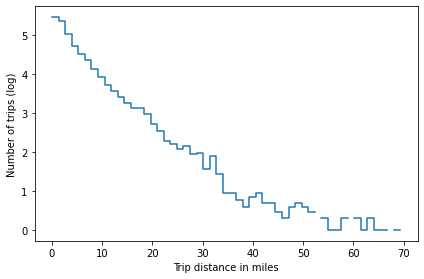

In [39]:
nyt.plot1d(nyt.trip_distance,f='log10')
plt.xlabel('Trip distance in miles'); plt.ylabel('Number of trips (log)')

In [44]:
# Filtre sur les courses de moins de 2h
nyt=nyt[nyt.trip_duration_min>0 and nyt.trip_duration_min<120]

In [50]:
nyt['trip_speed_mph']=nyt['trip_distance']/(nyt['trip_duration_min']/60)

In [55]:
nyt.dtypes

VendorID                          int64
lpep_pickup_datetime     datetime64[ns]
lpep_dropoff_datetime    datetime64[ns]
RatecodeID                        int64
PULocationID                      int64
DOLocationID                      int64
passenger_count                   int64
trip_distance                   float64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
ehail_fee                       float64
improvement_surcharge           float64
total_amount                    float64
payment_type                      int64
trip_type                       float64
pickup_hour                       int64
dropoff_hour                      int64
pickup_dayofweek                  int64
dropoff_dayofweek                 int64
trip_duration_min               float64
trip_speed_mph                  float64
dtype: object

In [66]:
nyt.describe()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,...,improvement_surcharge,total_amount,payment_type,trip_type,pickup_hour,dropoff_hour,pickup_dayofweek,dropoff_dayofweek,trip_duration_min,trip_speed_mph
dtype,int64,datetime64[ns],datetime64[ns],int64,int64,int64,int64,float64,float64,float64,...,float64,float64,int64,float64,int64,int64,int64,int64,float64,float64
count,735749,735749,735749,735749,735749,735749,735749,735749,735749,735749,...,735749,735749,735749,735749,735749,735749,735749,735749,735749,735749
NA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
mean,1.8291767980656446,1970-01-01T05:01:46.811669066,1970-01-01T05:15:13.808245344,1.0472212670353613,109.7314573312366,129.5757574933843,1.3645563908343743,2.82426540844824,12.159040773415937,0.3437089279088385,...,0.2964856221313504,14.490534951492412,1.4590179531334735,1.0117186703617673,13.83882546901185,13.903855798648724,2.898803804014684,2.9016240592919598,13.4499429379675,inf
std,0.376354,1.26733e+15,1.26732e+15,0.424984,74.1758,77.0035,1.04976,2.83949,8.84352,0.391517,...,0.0322794,9.86853,0.510545,0.107617,6.11776,6.17167,1.98507,1.98705,10.1919,NaN
min,1,2009-01-01T10:21:13.321406464,2009-01-01T11:16:11.856289792,1,1,1,0,0.51,0,0,...,0,0.01,1,1,0,0,0,0,0,0.303797
max,2,2018-04-05T04:12:12.356378624,2018-04-05T04:25:56.990099456,6,265,265,8,69.16,999.99,4.5,...,0.3,999.99,5,2,23,23,6,6,119.817,inf


In [67]:
#on garde des courses qui durent au moins 1 min et couvrent 1/2 mile
nyt=nyt[nyt.trip_duration_min>1 or nyt.trip_distance>0.5]
nyt['trip_speed_mph']=nyt['trip_distance']/(nyt['trip_duration_min']/60)

In [68]:
nyt['trip_speed_mph'].mean()

array(12.2457881)

C:\Users\dgr\AppData\Local\Continuum\anaconda3\lib\site-packages\vaex\viz\mpl.py:128: RuntimeWarning: divide by zero encountered in log10
  fgrid = f(grid)


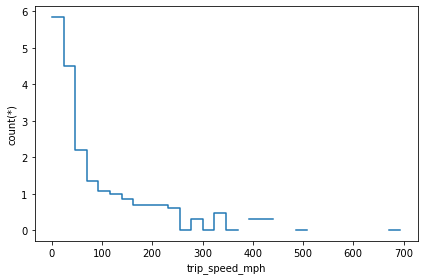

In [70]:
nyt.plot1d(nyt.trip_speed_mph,f='log10')

In [71]:
# Filtre sur les vitesses aberrantes
nyt=nyt[nyt.trip_speed_mph>1 and nyt.trip_speed_mph<60]

C:\Users\dgr\AppData\Local\Continuum\anaconda3\lib\site-packages\vaex\viz\mpl.py:128: RuntimeWarning: divide by zero encountered in log10
  fgrid = f(grid)
C:\Users\dgr\AppData\Local\Continuum\anaconda3\lib\site-packages\vaex\viz\mpl.py:128: RuntimeWarning: divide by zero encountered in log10
  fgrid = f(grid)
C:\Users\dgr\AppData\Local\Continuum\anaconda3\lib\site-packages\vaex\viz\mpl.py:128: RuntimeWarning: divide by zero encountered in log10
  fgrid = f(grid)


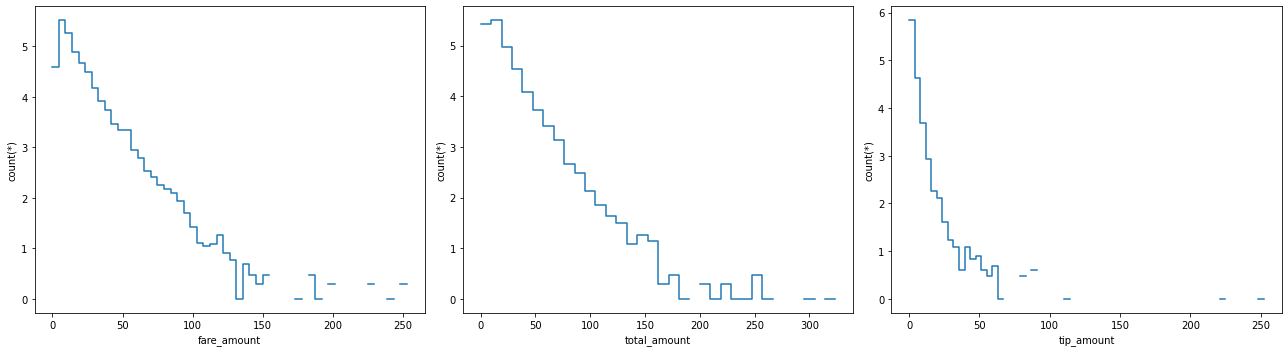

In [78]:
# Les montants des courses ont également des valeurs aberrantes : fare, total et tip
plt.figure(figsize=(18,5))
plt.subplot(131)
nyt.plot1d(nyt.fare_amount,f='log10')
plt.subplot(132)
nyt.plot1d(nyt.total_amount,f='log10')
plt.subplot(133)
nyt.plot1d(nyt.tip_amount,f='log10')

In [79]:
# Filtre sur les vitesses aberrantes
nyt=nyt[nyt.total_amount<200 and nyt.tip_amount>0 and nyt.tip_amount<200 and nyt.fare_amount>0 and nyt.fare_amount<200]

In [80]:
# Combien a t'on filtré
len(nyt)

734641

In [90]:
# on lance le calcul quand on a besoin (lazy)
nyt['tip_pct']=nyt.tip_amount/nyt.total_amount*100 # 0 sec, enr juste la formule

In [67]:
# compute wehn needed
nyt.tip_pct.mean()

<string>:1: RuntimeWarning: invalid value encountered in true_divide


array(6.58259335)

In [91]:
nyt.dtypes

VendorID                          int64
lpep_pickup_datetime     datetime64[ns]
lpep_dropoff_datetime    datetime64[ns]
RatecodeID                        int64
PULocationID                      int64
DOLocationID                      int64
passenger_count                   int64
trip_distance                   float64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
ehail_fee                       float64
improvement_surcharge           float64
total_amount                    float64
payment_type                      int64
trip_type                       float64
pickup_hour                       int64
dropoff_hour                      int64
pickup_dayofweek                  int64
dropoff_dayofweek                 int64
trip_duration_min               float64
trip_speed_mph                  float64
tip_pct                         float64


In [93]:
from matplotlib import cm
plt.figure(figsize=(18,5))
nyt.plot('pickup_hour','pickup_dayofweek',what='mean(tip_pct)',colorbar=True,colormap=cm_plusmin)


NameError: name 'cm_plusmin' is not defined

<Figure size 1296x360 with 0 Axes>

In [ ]:
# Vaex implements parallelized, highly performant groupby operations, especially when using categories (>1 billion/second).

In [74]:
# nb de lignes par modalites passenger_count

# dabord il faut typer avec categorize
nyt=nyt.categorize(nyt.passenger_count)
nyt.groupby(dff.passenger_count,agg='count')

AttributeError: 'DataFrame' object has no attribute 'categorize'